In [1]:
# %% [Markdown]
# ## Librerias
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, f1_score
from sklearn.model_selection import ParameterGrid

In [10]:
# ## 1. Leemos el dataset, archivo adjunto.
df = pd.read_csv(r'.\Resources\CreditCard.csv')
df.head()

,card,reports,age,income,share,expenditure,owner,selfemp,dependents,months,majorcards,active
0,yes,0,37.66667,4.5200,0.033270,124.983300,yes,no,3,54,1,12
1,yes,0,33.25000,2.4200,0.005217,9.854167,no,no,3,34,1,13
2,yes,0,33.66667,4.5000,0.004156,15.000000,yes,no,4,58,1,5
3,yes,0,30.50000,2.5400,0.065214,137.869200,no,no,0,25,1,7
4,yes,0,32.16667,9.7867,0.067051,546.503300,yes,no,2,64,1,5


In [12]:
df

,card,reports,age,income,share,expenditure,owner,selfemp,dependents,months,majorcards,active
0,yes,0,37.66667,4.5200,0.033270,124.983300,yes,no,3,54,1,12
1,yes,0,33.25000,2.4200,0.005217,9.854167,no,no,3,34,1,13
2,yes,0,33.66667,4.5000,0.004156,15.000000,yes,no,4,58,1,5
3,yes,0,30.50000,2.5400,0.065214,137.869200,no,no,0,25,1,7
4,yes,0,32.16667,9.7867,0.067051,546.503300,yes,no,2,64,1,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1314,yes,0,33.58333,4.5660,0.002146,7.333333,yes,no,0,94,1,19
1315,no,5,23.91667,3.1920,0.000376,0.000000,no,no,3,12,1,5
1316,yes,0,40.58333,4.6000,0.026513,101.298300,yes,no,2,1,1,2
1317,yes,0,32.83333,3.7000,0.008999,26.996670,no,yes,0,60,1,7


In [13]:
# ## 2. Preparamos el dataset
df = pd.get_dummies(data=df, drop_first=True)

In [14]:
df

,reports,age,income,share,expenditure,dependents,months,majorcards,active,card_yes,owner_yes,selfemp_yes
0,0,37.66667,4.5200,0.033270,124.983300,3,54,1,12,True,True,False
1,0,33.25000,2.4200,0.005217,9.854167,3,34,1,13,True,False,False
2,0,33.66667,4.5000,0.004156,15.000000,4,58,1,5,True,True,False
3,0,30.50000,2.5400,0.065214,137.869200,0,25,1,7,True,False,False
4,0,32.16667,9.7867,0.067051,546.503300,2,64,1,5,True,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
1314,0,33.58333,4.5660,0.002146,7.333333,0,94,1,19,True,True,False
1315,5,23.91667,3.1920,0.000376,0.000000,3,12,1,5,False,False,False
1316,0,40.58333,4.6000,0.026513,101.298300,2,1,1,2,True,True,False
1317,0,32.83333,3.7000,0.008999,26.996670,0,60,1,7,True,False,True


In [15]:
#Isolated X and y
y = df.card_yes
X = df.drop(columns=['card_yes'])
X.head()

,reports,age,income,share,expenditure,dependents,months,majorcards,active,owner_yes,selfemp_yes
0,0,37.66667,4.5200,0.033270,124.983300,3,54,1,12,True,False
1,0,33.25000,2.4200,0.005217,9.854167,3,34,1,13,False,False
2,0,33.66667,4.5000,0.004156,15.000000,4,58,1,5,True,False
3,0,30.50000,2.5400,0.065214,137.869200,0,25,1,7,False,False
4,0,32.16667,9.7867,0.067051,546.503300,2,64,1,5,True,False


In [16]:
y

0        True
1        True
2        True
3        True
4        True
        ...  
1314     True
1315    False
1316     True
1317     True
1318     True
Name: card_yes, Length: 1319, dtype: bool

In [4]:
# ## 3. División de datos de entrenamiento y de prueba
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.2,
                                                    random_state = 42,
                                                    stratify = y)
len(X_train), len(X_test), len(y_train), len(y_test)

(1055, 264, 1055, 264)

In [5]:
# ## 4. Modelo de Random Forest creado
model = RandomForestClassifier(n_estimators = 50,
                               random_state = 42)

model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=50, random_state=42)

In [6]:
# ## 5. Predicción
model_predict = model.predict(X_test)
print(classification_report(y_test, model_predict))

              precision    recall  f1-score   support

       False       0.88      1.00      0.94        59
        True       1.00      0.96      0.98       205

    accuracy                           0.97       264
   macro avg       0.94      0.98      0.96       264
weighted avg       0.97      0.97      0.97       264



In [7]:
# ## 6. F1 Score
f1_score(y_test, model_predict)

0.9800995024875622

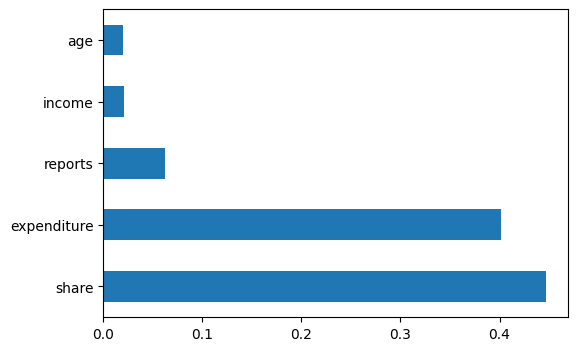

In [8]:
# ## 7. Trazando nuestro output
importance = pd.Series(model.feature_importances_,
                       index = X_train.columns.values)
importance.nlargest(5).plot(kind='barh',
                            figsize = (6,4));

In [9]:
# ## 8. Sección de ajuste de parámetros
param_grid = {'n_estimators': range(50, 500, 50)}
grid = ParameterGrid(param_grid)


#list
f1score = []
for params in grid:
  model = RandomForestClassifier(n_estimators = params['n_estimators'],
                                 random_state = 1502)
  model.fit(X_train, y_train)

  predict = model.predict(X_test)

  f1 = f1_score(y_test, predict)

  f1score.append(f1)

grid[np.argmax(f1)]

{'n_estimators': 50}